In [29]:
import math as maths

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from hackathon2025 import get_coords
import intake
import easygems.healpix as egh

import MCS_snapshots as msnap

In [1]:
cd .. 

/home/users/cornkle/pythonWorkspace/proj_CEH


In [30]:
# sims = [
#     # 'glm.n1280_CoMA9', # currently has no zarr store.
#     'glm.n2560_RAL3p3',
#     'glm.n1280_GAL9_nest',
#     'SAmer_km4p4_RAL3P3.n1280_GAL9_nest',
#     'Africa_km4p4_RAL3P3.n1280_GAL9_nest',
#     'SEA_km4p4_RAL3P3.n1280_GAL9_nest',
#     'SAmer_km4p4_CoMA9_TBv1.n1280_GAL9_nest',
#     'Africa_km4p4_CoMA9_TBv1.n1280_GAL9_nest',
#     'SEA_km4p4_CoMA9_TBv1.n1280_GAL9_nest',
#     'CTC_km4p4_RAL3P3.n1280_GAL9_nest',
#     'CTC_km4p4_CoMA9_TBv1.n1280_GAL9_nest'
# ]

# um_Africa_km4p4_RAL3P3_n1280_GAL9_nest - Africa LAM convection permitting nested GAL9 
# um_Africa_km4p4_CoMA9_TBv1_n1280_GAL9_nest - Africa LAM CoMorph nested GAL9
# um_CTC_km4p4_RAL3P3_n1280_GAL9_nest - cyclic tropical channel convection permitting nested GAL9
# um_CTC_km4p4_CoMA9_TBv1_n1280_GAL9_nest - cyclic tropical channel CoMorph nested GAL9
# um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest - South America LAM convection permitting nested GAL9
# um_SAmer_km4p4_CoMA9_TBv1_n1280_GAL9_nest - South America LAM CoMorph nested GAL9
# um_SEA_km4p4_RAL3P3_n1280_GAL9_nest - South East Asia LAM convection permitting nested GAL9
# um_glm_n1280_CoMA9_TBv1p2 - global 10km CoMorph scheme
# um_glm_n1280_GAL9 - global 10km parameter 6A scheme
# um_glm_n2560_RAL3p3 - global 5km convection permitting 

In [73]:
REGIONS = {'africa': [(-10, 20.),(7,22)], 'samerica': [(-86., -26.),(-30., 14.)], 'sea': [(90., 154.),(-18., 25.)]}

In [74]:
def read_sim(sname, zlevel, freq):

    cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']
    sim_name = sname
    zoom_level = zlevel
    frequency = freq
    # Show example URL
    ds = cat[sname](time=freq, zoom=zlevel).to_dask()
    return ds

In [75]:
zlevel=8
region_sim_1h = read_sim('um_Africa_km4p4_RAL3P3_n1280_GAL9_nest', zlevel, 'PT1H')
region_sim_3h = read_sim('um_Africa_km4p4_RAL3P3_n1280_GAL9_nest', zlevel, 'PT3H').sel(pressure=600)
global_sim_1h = read_sim('um_glm_n2560_RAL3p3', zlevel, 'PT1H')
global_sim_3h = read_sim('um_glm_n2560_RAL3p3', zlevel, 'PT3H').sel(pressure=600)

/home/users/cornkle/programs/miniconda3/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/home/users/cornkle/programs/miniconda3/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/home/users/cornkle/programs/miniconda3/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more 

<Figure size 640x480 with 0 Axes>

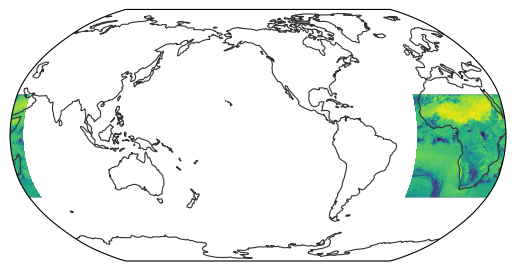

In [76]:
# Quick plot of global T at 1.5m
egh.healpix_show(region_sim_1h.rlut.isel(time=1500))

In [77]:
# Suppose ds1 and ds2 are your two xarray datasets
shared_times = np.intersect1d(region_sim_3h.time,region_sim_1h.time)

In [79]:
region_sim_pl = region_sim_3h.sel(time=shared_times)
region_sim_srfc = region_sim_1h.sel(time=shared_times)

In [80]:
global_sim_pl = global_sim_3h.sel(time=shared_times)
global_sim_srfc = global_sim_1h.sel(time=shared_times)

In [81]:
reg_rlut = region_sim_srfc['rlut']
reg_pr = region_sim_srfc['pr']
reg_vv = region_sim_pl['wa']

In [82]:
glo_rlut = global_sim_srfc['rlut']
glo_pr = global_sim_srfc['pr']
glo_vv = global_sim_pl['wa']

<Figure size 640x480 with 0 Axes>

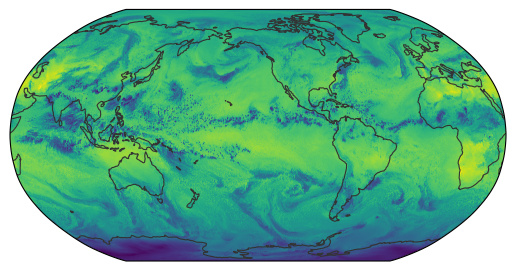

In [83]:
egh.healpix_show(glo_rlut.isel(time=1500))

In [84]:
regs = REGIONS
coords = get_coords.get_nn_lon_lat_index(zoom=zlevel, lon_range=regs['africa'][0], lat_range=regs['africa'][1])

In [85]:
def olr_to_bt(olr):
    #Application of Stefan-Boltzmann law
    sigma = 5.670373e-8
    tf = (olr/sigma)**0.25
    #Convert from bb to empirical BT (degC) - Yang and Slingo, 2001
    a = 1.228
    b = -1.106e-3
    Tb = (-a + np.sqrt(a**2 + 4*b*tf))/(2*b)
    return Tb - 273.15

In [172]:
dirs = {'reg_rlut' : reg_rlut, 'reg_pr' : reg_pr, 'reg_vv' : reg_vv, 'glo_rlut' : glo_rlut, 'glo_pr' : glo_pr, 'glo_vv' : glo_vv}

for k in dirs.keys():
    print('Doing', k)
    dirs[k] = dirs[k].sel(cell=coords).sel(time=slice('2020-06-01T00:00:00.000000000', '2020-10-30T00:00:00.000000000'))  #isel(time=slice(960,1440)) #.
    # if 'rlut' in k:
    #     ctt = olr_to_bt(dirs[k].values)
    #     dirs[k].values = ctt

Doing reg_rlut
Doing reg_pr
Doing reg_vv
Doing glo_rlut
Doing glo_pr
Doing glo_vv


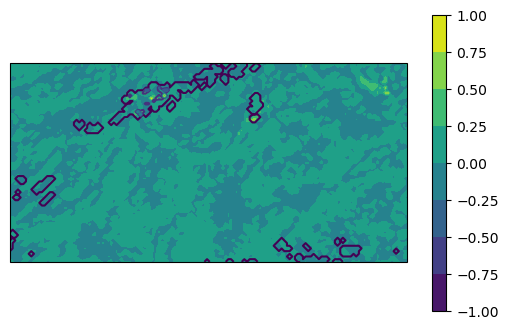

In [173]:
f=plt.figure()

a1 = f.add_subplot(111,projection=ccrs.PlateCarree())
con1 = plt.contourf(dirs['reg_pr'].lon,dirs['reg_pr'].lat,dirs['reg_vv'].isel(time=100))
plt.colorbar(con1,shrink=0.8)
con1 = plt.contour(dirs['reg_pr'].lon,dirs['reg_pr'].lat,dirs['reg_pr'].isel(time=100)*3600)
a1.grid()
a1.coastlines()
# a1.set_yticks(np.linspace(dirs['reg_rlut'].lat.min(),dirs['reg_rlut'].lat.max(),5))
# a1.set_xticks(np.linspace(dirs['reg_rlut'].lon.min(),dirs['reg_rlut'].lon.max(),5))


plt.show()

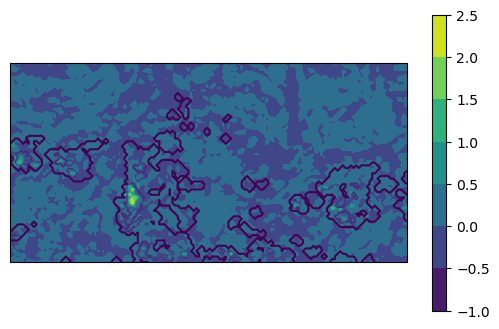

In [174]:
f=plt.figure()

a1 = f.add_subplot(111,projection=ccrs.PlateCarree())
con1 = plt.contourf(dirs['glo_pr'].lon,dirs['glo_pr'].lat,dirs['glo_vv'].isel(time=200))
plt.colorbar(con1,shrink=0.8)
con1 = plt.contour(dirs['glo_pr'].lon,dirs['glo_pr'].lat,dirs['glo_pr'].isel(time=200)*3600)
a1.grid()
a1.coastlines()
# a1.set_yticks(np.linspace(dirs['reg_rlut'].lat.min(),dirs['reg_rlut'].lat.max(),5))
# a1.set_xticks(np.linspace(dirs['reg_rlut'].lon.min(),dirs['reg_rlut'].lon.max(),5))


plt.show()

In [175]:
dirs['glo_pr']

<xarray.DataArray 'pr' (time: 1209, lat: 75, lon: 150)> Size: 54MB
dask.array<getitem, shape=(1209, 75, 150), dtype=float32, chunksize=(15, 75, 150), chunktype=numpy.ndarray>
Coordinates:
    cell     (lat, lon) int64 90kB 302926 302927 302936 ... 317269 32938 32938
    crs      float64 8B ...
  * time     (time) datetime64[ns] 10kB 2020-06-01 ... 2020-10-30
  * lat      (lat) float64 600B 7.0 7.203 7.405 7.608 ... 21.39 21.59 21.8 22.0
  * lon      (lon) float64 1kB -10.0 -9.799 -9.597 -9.396 ... 19.6 19.8 20.0
Attributes:
    STASH:          [1, 4, 203]
    UM_name:        stratiform_rainfall_flux
    cell_methods:   time: mean (interval: 1 hour)
    grid_mapping:   healpix_nested
    healpix_zoom:   8
    long_name:      precipitation_flux
    notes:          hourly mean - time index shifted from half past the hour ...
    source:         Data from Met Office Unified Model
    standard_name:  stratiform_rainfall_flux
    um_version:     13.5
    units:          kg m-2 s-1

In [185]:
def basic_1d_binning_mean(xvar, xbins):
    """
    :param xvar: xvar of the 2dhist
    :param yvar: yvar of the 2d hist
    :param xbins: bins to use for the xvar
    :param ybins: bins to use for the yvar
    :param varlist: dictionary of variables to put into histogram
    :param varpick: list of variables in dic to calculate
    :return:
    """
    outdic = {}
    outdic['nb'] = []


    for issh, shl in enumerate(xbins[0:-1]):

        mask = (xvar > shl) & (xvar <= xbins[issh + 1])

        outdic['nb'].append(np.nanmean(xvar[mask]))



    outdic['xbins'] = (np.round(xbins[0:-1]+((xbins[1::]-xbins[0:-1])/2),2))


    return outdic

def var2_binning_mean(xvar, yvar, xbins):
    """
    :param xvar: xvar of the 2dhist
    :param yvar: yvar of the 2d hist
    :param xbins: bins to use for the xvar
    :param ybins: bins to use for the yvar
    :param varlist: dictionary of variables to put into histogram
    :param varpick: list of variables in dic to calculate
    :return:
    """
    outdic = {}
    outdic['y'] = []
    outdic['ycount'] = []
    outdic['ystd'] = []


    for issh, shl in enumerate(xbins[0:-1]):

        mask = (xvar > shl) & (xvar <= xbins[issh + 1])

        #outdic['y'].append(np.nanmean(yvar[mask]))
        #print(shl)

        try:
            #outdic['y'].append(np.percentile(yvar[mask],95))
            #outdic['y'].append(np.median(yvar[mask]))
            #ipdb.set_trace()
            outdic['y'].append(np.mean(yvar[mask]))
            outdic['ystd'].append(np.std(yvar[mask]))
            outdic['ycount'].append(np.sum(np.isfinite(yvar[mask])))
            #ipdb.set_trace()

        except:
            # outdic['y'].append(np.nan)
            # outdic['ystd'].append(np.nan)
            # outdic['ycount'].append(np.nan)

            outdic['y'].append(0)
            outdic['ystd'].append(0)
            outdic['ycount'].append(0)

        #ipdb.set_trace()

    outdic['xbins'] = (np.round(xbins[0:-1]+((xbins[1::]-xbins[0:-1])/2),2))


    return outdic

def basic_1d_binning(xvar, xbins, percentage=False):
    """
    :param xvar: xvar of the 2dhist
    :param yvar: yvar of the 2d hist
    :param xbins: bins to use for the xvar
    :param ybins: bins to use for the yvar
    :param varlist: dictionary of variables to put into histogram
    :param varpick: list of variables in dic to calculate
    :return:
    """
    outdic = {}
    outdic['nb'] = []


    for issh, shl in enumerate(xbins[0:-1]):

        poss_ds = np.sum((xvar > shl) & (xvar <= xbins[issh + 1]))

        if percentage:
            divs = xvar.size
        else:
            divs = 1
        outdic['nb'].append(poss_ds/divs)



    outdic['xbins'] = (np.round(xbins[0:-1]+((xbins[1::]-xbins[0:-1])/2),2))


    return outdic

In [177]:
pdic_reg = var2_binning_mean(dirs['reg_vv'].values, dirs['reg_pr'].values*3600, np.linspace(np.percentile(dirs['reg_vv'].values,5),np.percentile(dirs['reg_vv'].values,95), 10))

In [178]:
pdic_global = var2_binning_mean(dirs['glo_vv'].values, dirs['glo_pr'].values*3600, np.linspace(np.percentile(dirs['reg_vv'].values,5),np.percentile(dirs['reg_vv'].values,95), 10))

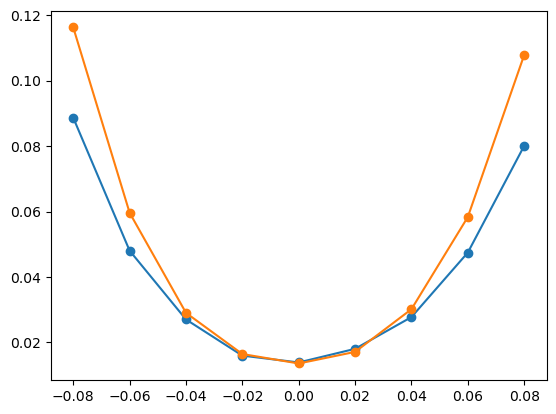

In [179]:
plt.plot(pdic_reg['xbins'], pdic_reg['y'], label='regional', marker='o')
plt.plot(pdic_global['xbins'], pdic_global['y'], label='global', marker='o')

In [192]:
pdic_reg = basic_1d_binning(dirs['reg_pr'].values*3600, np.linspace(1,np.max(dirs['reg_pr'].values*3600), 10))

In [193]:
pdic_global = basic_1d_binning(dirs['glo_pr'].values*3600, np.linspace(1,np.max(dirs['glo_pr'].values*3600), 10))

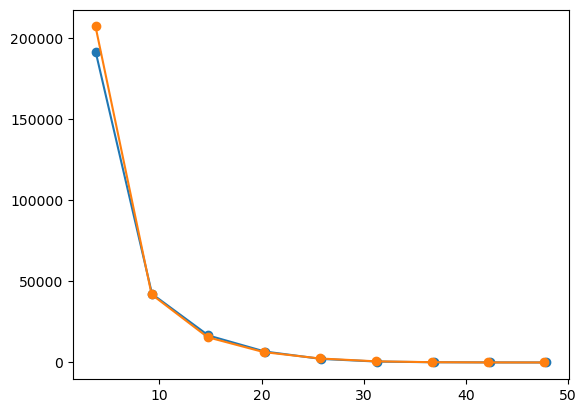

In [194]:
plt.plot(pdic_reg['xbins'], pdic_reg['nb'], label='regional', marker='o')
plt.plot(pdic_global['xbins'], pdic_global['nb'], label='global', marker='o')

In [162]:
dirs['glo_pr'].values.shape

(233, 75, 150)

In [167]:
np.linspace(0,np.max(dirs['reg_pr'].values*3600), 10)

array([ 0.       ,  5.6251297, 11.250259 , 16.87539  , 22.500519 ,
       28.125648 , 33.75078  , 39.375908 , 45.001038 , 50.626167 ],
      dtype=float32)

In [171]:
np.sum(dirs['reg_pr'].values*3600>35)

np.int64(65)